# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_:
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Soriano, Edneil
- _Student No._: 20XX-XXXXX
- _Section_: ANO SECTION NIYO HEHE

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 (You may edit this subsection)

![Description](figures/sample.png)

EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` (for more info, check bottomost cell under Section 3). Make sure the figure has complete elements.

### Problem 2 (You may edit this subsection)

EDIT ME. See instruction above for what to include. Insert your discussion here. This is not related to Problem 1. Discuss your key results with ~150 words.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.


In [ ]:
# code here

coeffs = [(-11)**i for i in reversed(range(8))]
x = 11.01

def polyEvalNaive(coeffs, x):
  return sum(c*(x**l) for l,c in enumerate(reversed(coeffs)))

polyEvalNaive(coeffs, x)



-379043280256570.44

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree).

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [ ]:
# code here
# coeffs = [(-11)**i for i in reversed(range(8))]

coeffs = [(-11)**i for i in reversed(range(8))]
x = 11.01

def horner(coeffs, x):
  result = coeffs[0]
  for c in coeffs[1:]:
    result = result*x + c
  return result

horner(coeffs, x)

# The two alghorithmns yield a similar result but have different decimal values
# The naive method directly multiplies large values together as well as adding these large values to significacntly smaller ones. This makes it more prone to catastrophic cancellation.
# Horner's rule allows the addition to be done gradually which minimizes catastrophic cancellation. The addition is done after each mmultiplication.

-379043280256570.5

Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

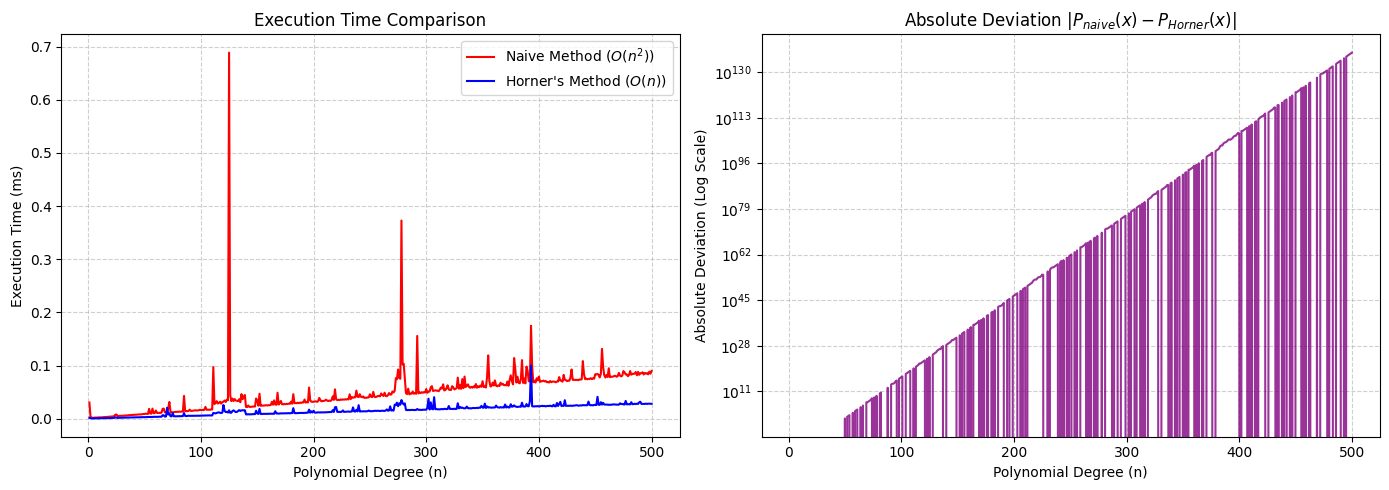

In [ ]:

import time
import matplotlib.pyplot as plt

# Generate coefficients
def get_coeffs(degree):
    return [((-1)**i) * (i + 1) for i in reversed(range(degree + 1))]


def poly_eval_naive(coeffs, x):
    n = len(coeffs) - 1
    return sum(c * (x ** (n - i)) for i, c in enumerate(coeffs))


def poly_eval_horner(coeffs, x):
    result = 0.0
    for c in coeffs:
        result = result * x + c
    return result

# Benchmark Execution
degrees = list(range(1, 501))
x = 2.0

time_naive = []
time_horner = []
absolute_deviations = []

for n in degrees:
    coeffs = get_coeffs(n)

    # Naive Method Time
    t0 = time.perf_counter()
    val_naive = poly_eval_naive(coeffs, x)
    t1 = time.perf_counter()
    time_naive.append((t1 - t0) * 1000)  # Convert to milliseconds

    # Horner Rule Time
    t0 = time.perf_counter()
    val_horner = poly_eval_horner(coeffs, x)
    t1 = time.perf_counter()
    time_horner.append((t1 - t0) * 1000)


    absolute_deviations.append(abs(val_naive - val_horner))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degrees, time_naive, label="Naive Method", color="red", alpha=1)
axes[0].plot(degrees, time_horner, label="Horner's Method", color="blue", alpha=1)
axes[0].set_title("Execution Time Comparison")
axes[0].set_xlabel("Polynomial Degree (n)")
axes[0].set_ylabel("Execution Time (ms)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)


axes[1].plot(degrees, absolute_deviations, color="green", alpha=0.8)
axes[1].set_yscale("log")  # Log scale
axes[1].set_title("Absolute Deviation $|P_{naive}(x) - P_{Horner}(x)|$")
axes[1].set_xlabel("Polynomial Degree (n)")
axes[1].set_ylabel("Absolute Deviation (Log Scale)")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# A for loop is made for each polynomial degree from 1 to 500. In each iteration, the time is taken for each computation to take, using perf_counter, for both methods.
# Also, the absolute deviation between the two methods are taken in each loop. These are then both plotted with the x axis being the polynomial degree.
# The naive method has a big o time complexity of n squared due to the repeated multiplication while Horner's method has a n time complexity due to its sequenctial factoring of x.
# This is shown in the execution time vs degree graph where the naive method takes a significntly more amount of time to execute as compared to Horner's method.
# It is also noted that the time for the naive method tends to linearily increase in time in a logarithmic scale taken while horner's method has an almost constant time executed, though both experience
# randm spikes in execution time, with the naive method having more frequent and drastic increases.

# The absolute deviaton show a linear increase with polynomial degree, showcasing the increasing effect of catastrophic cancellation at higher degrees due to larger values.
# There are also certain degrees where the absolute deviation is minimal no matter the degree.

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

<>:37: SyntaxWarning: invalid escape sequence '\_'
<>:37: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_1783/2924383762.py:37: SyntaxWarning: invalid escape sequence '\_'
  axes[1].set_title("Absolute Error $|exp\_horner(x) - np.exp(x)|$", fontsize=12, fontweight="bold")


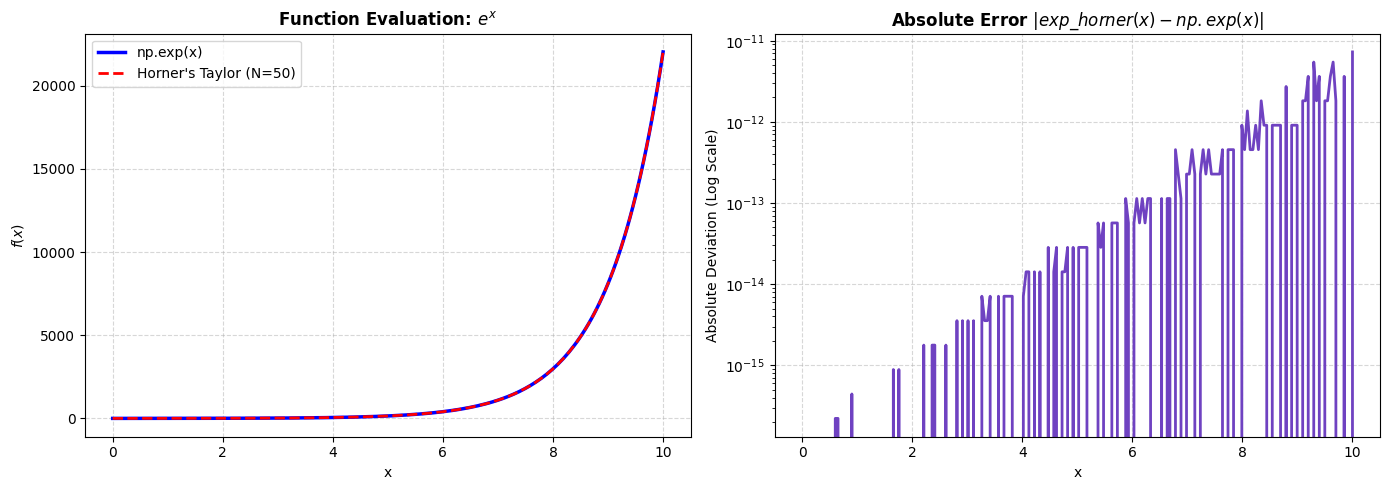

In [5]:
# code

import numpy as np
import matplotlib.pyplot as plt


def exp_horner(x, N=50): # N being the amount of terms used for the Taylor Series

    result = 1.0
    for k in range(N, 0, -1): # Starting from the innermost parenthesis, which contains the highest degree polynomial, to zero. Thus range must be from N to 0 with a -1 step.
        result = 1.0 + (x / k) * result # Recursive use of Horner's Rule. This also serves to emulate the factorial of the series.
    return result

x_values = np.linspace(0, 10, 200)


y_horner = [exp_horner(xi, N=50) for xi in x_values]


y_numpy = np.exp(x_values)

abs_error = np.abs(np.array(y_horner) - y_numpy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(x_values, y_numpy, label="np.exp(x)", color="blue", linewidth=2.5)
axes[0].plot(x_values, y_horner, label="Horner's Taylor (N=50)", color="red", linestyle="--", linewidth=2)
axes[0].set_title("Function Evaluation: $e^x$", fontsize=12, fontweight="bold")
axes[0].set_xlabel("x", fontsize=10)
axes[0].set_ylabel("$f(x)$", fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(x_values, abs_error, color="#6f42c1", linewidth=2)
axes[1].set_yscale("log")
axes[1].set_title("Absolute Error $|exp\_horner(x) - np.exp(x)|$", fontsize=12, fontweight="bold")
axes[1].set_xlabel("x", fontsize=10)
axes[1].set_ylabel("Absolute Deviation (Log Scale)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# The taylor's series is first factored out for each x then is used as the working equation of the algorithm.
# In this case, e^x would be e^x = 1 + x(1 + x/2(...(1 + x/N))), where N is the degree at which the Taylor series is taken.
# Using Horner's rule, this equation would be performed from the innermost parenthesis to the outermost. This allows a recursive loop where each parenthesis serves as an input to the next.
#

# Discussion:
# When comparing the in built function to the Horner's Taylor series, the plots are nearly identical. Looking at the absolute error, the difference are also very low, where
# it reaches logarithmically small ranges. However, it is noted that the error still increases with an increase of x value, which can be attributed to catastrophic cancellation.
# There are points where both functions are equal, as seen as the repeated zero absolute difference throughout the plot.

Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4186/2224226366.py:38: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title("Function Evaluation: $\sin(x)$", fontsize=12, fontweight="bold")
/tmp/ipykernel_4186/2224226366.py:47: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title("Absolute Error $|\sin_{horner}(x) - \sin_{numpy}(x)|$", fontsize=12, fontweight="bold")


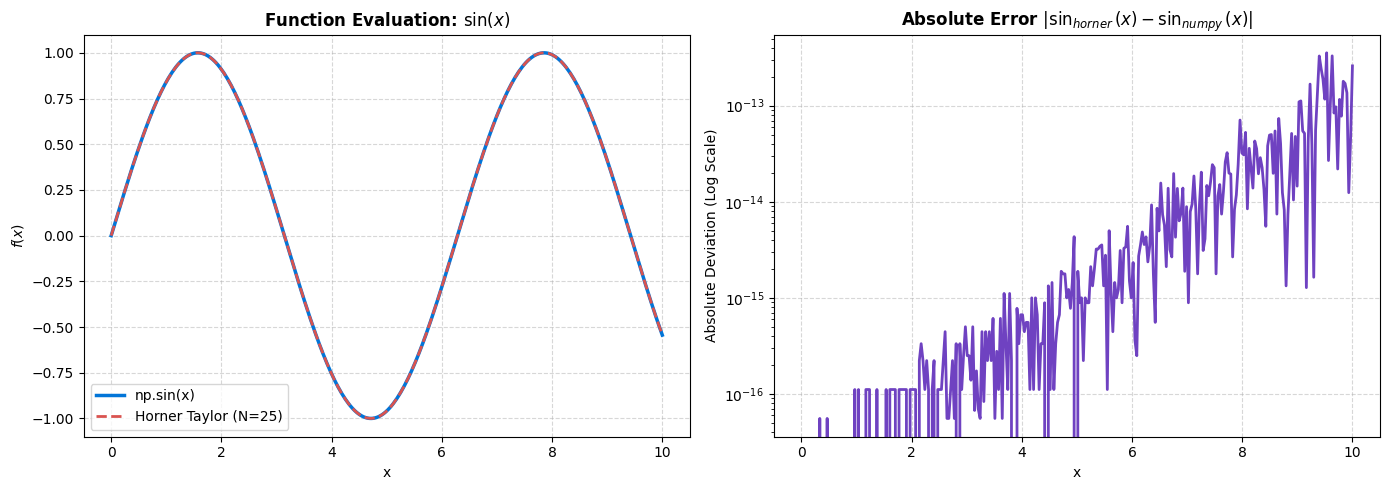

In [ ]:
# code
import numpy as np
import matplotlib.pyplot as plt

def sin_horner(x, N=20):

    j = x * x  # first X^2 for all iterations
    result = 1.0

    # Recursive Taylor series
    for k in range(N, 0, -1):
        denom = (2 * k) * (2 * k + 1) # Denominator of the taylor series representing the factorial
        result = 1.0 - (j / denom) * result

    return x * result

x_values = np.linspace(0, 10, 300)

# Horner Taylor Sine
y_horner = [sin_horner(xi, N=25) for xi in x_values]

# Built in Sine
y_numpy = np.sin(x_values)

# Absolute Error over X
abs_error = np.abs(np.array(y_horner) - y_numpy)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(x_values, y_numpy, label="np.sin(x)", color="#0275d8", linewidth=2.5)
axes[0].plot(x_values, y_horner, label="Horner Taylor (N=25)", color="#d9534f", linestyle="--", linewidth=2)
axes[0].set_title("Function Evaluation: $\sin(x)$", fontsize=12, fontweight="bold")
axes[0].set_xlabel("x", fontsize=10)
axes[0].set_ylabel("$f(x)$", fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)


axes[1].plot(x_values, abs_error, color="#6f42c1", linewidth=2)
axes[1].set_yscale("log")
axes[1].set_title("Absolute Error $|\sin_{horner}(x) - \sin_{numpy}(x)|$", fontsize=12, fontweight="bold")
axes[1].set_xlabel("x", fontsize=10)
axes[1].set_ylabel("Absolute Deviation (Log Scale)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# The taylor's series is first factored out for each x then is used as the working equation of the algorithm.
# In this case, e^x would be e^x = 1 - (1 - x^2/6 (1 - .. (1 - x^2/(2N(2N + 1)))), where N is the degree at which the Taylor series is taken.
# The denominator acts as a way to perform factorials, particularly (2n+1)!. The initial result is always 1, representing the innermost paranthesis where it is just the first iteration.
# Using Horner's rule, this equation would be performed from the innermost parenthesis to the outermost. This allows a recursive loop where each parenthesis serves as an input to the next.
#

# Discussion:
# When comparing the in built function to the Horner's Taylor series, the plots are nearly identical. Looking at the absolute error, the difference are also very low, where
# it reaches logarithmically small ranges. However, it is noted that the error still increases with an increase of x value, which can be attributed to catastrophic cancellation.
# There are points where both functions are equal, as seen as the repeated zero absolute difference throughout the plot. In the cae of sine, the absolute error oscillates more frequently
# and is rarely equal to the actual function.

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html).

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [ ]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [ ]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [ ]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [ ]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [ ]:
# you can write truthiness conditionals more succinctly as
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [ ]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [ ]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [ ]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [ ]:
# Tuples are primarily used to bundle related pieces of data together,
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [ ]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [ ]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y)

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [ ]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties
# but keeps references to any nested objects, meaning changes to nested data affect the original.
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [ ]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")
print(f"Copied:   {shallow_copied}")

# modifying a nested mutable element
shallow_copied[2][0] = "changed"
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")
print(f"Copied:   {shallow_copied}")

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed"
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")
print(f"Copied:   {deep_copied}")

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [ ]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [ ]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [ ]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either
cosder(0.)
#or
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [ ]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [ ]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)]
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

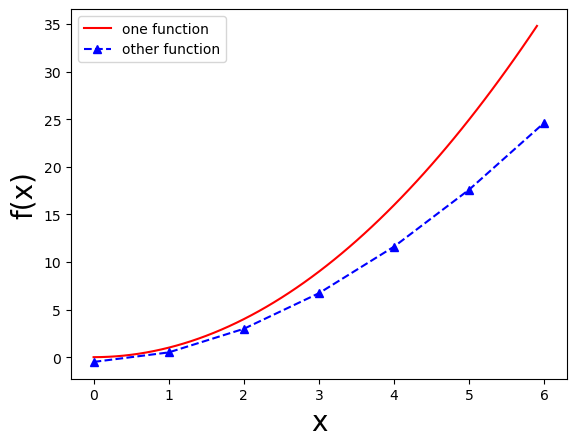

In [ ]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

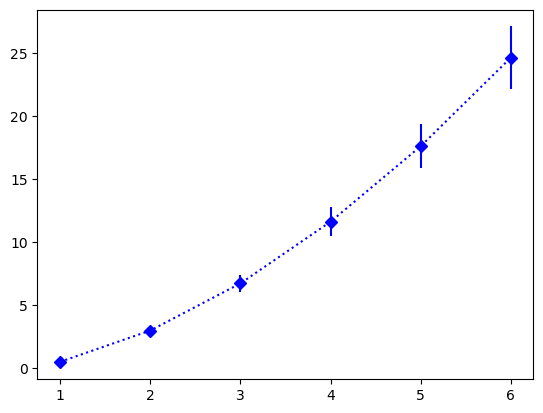

In [ ]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [ ]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [ ]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])